2.1理论计算题

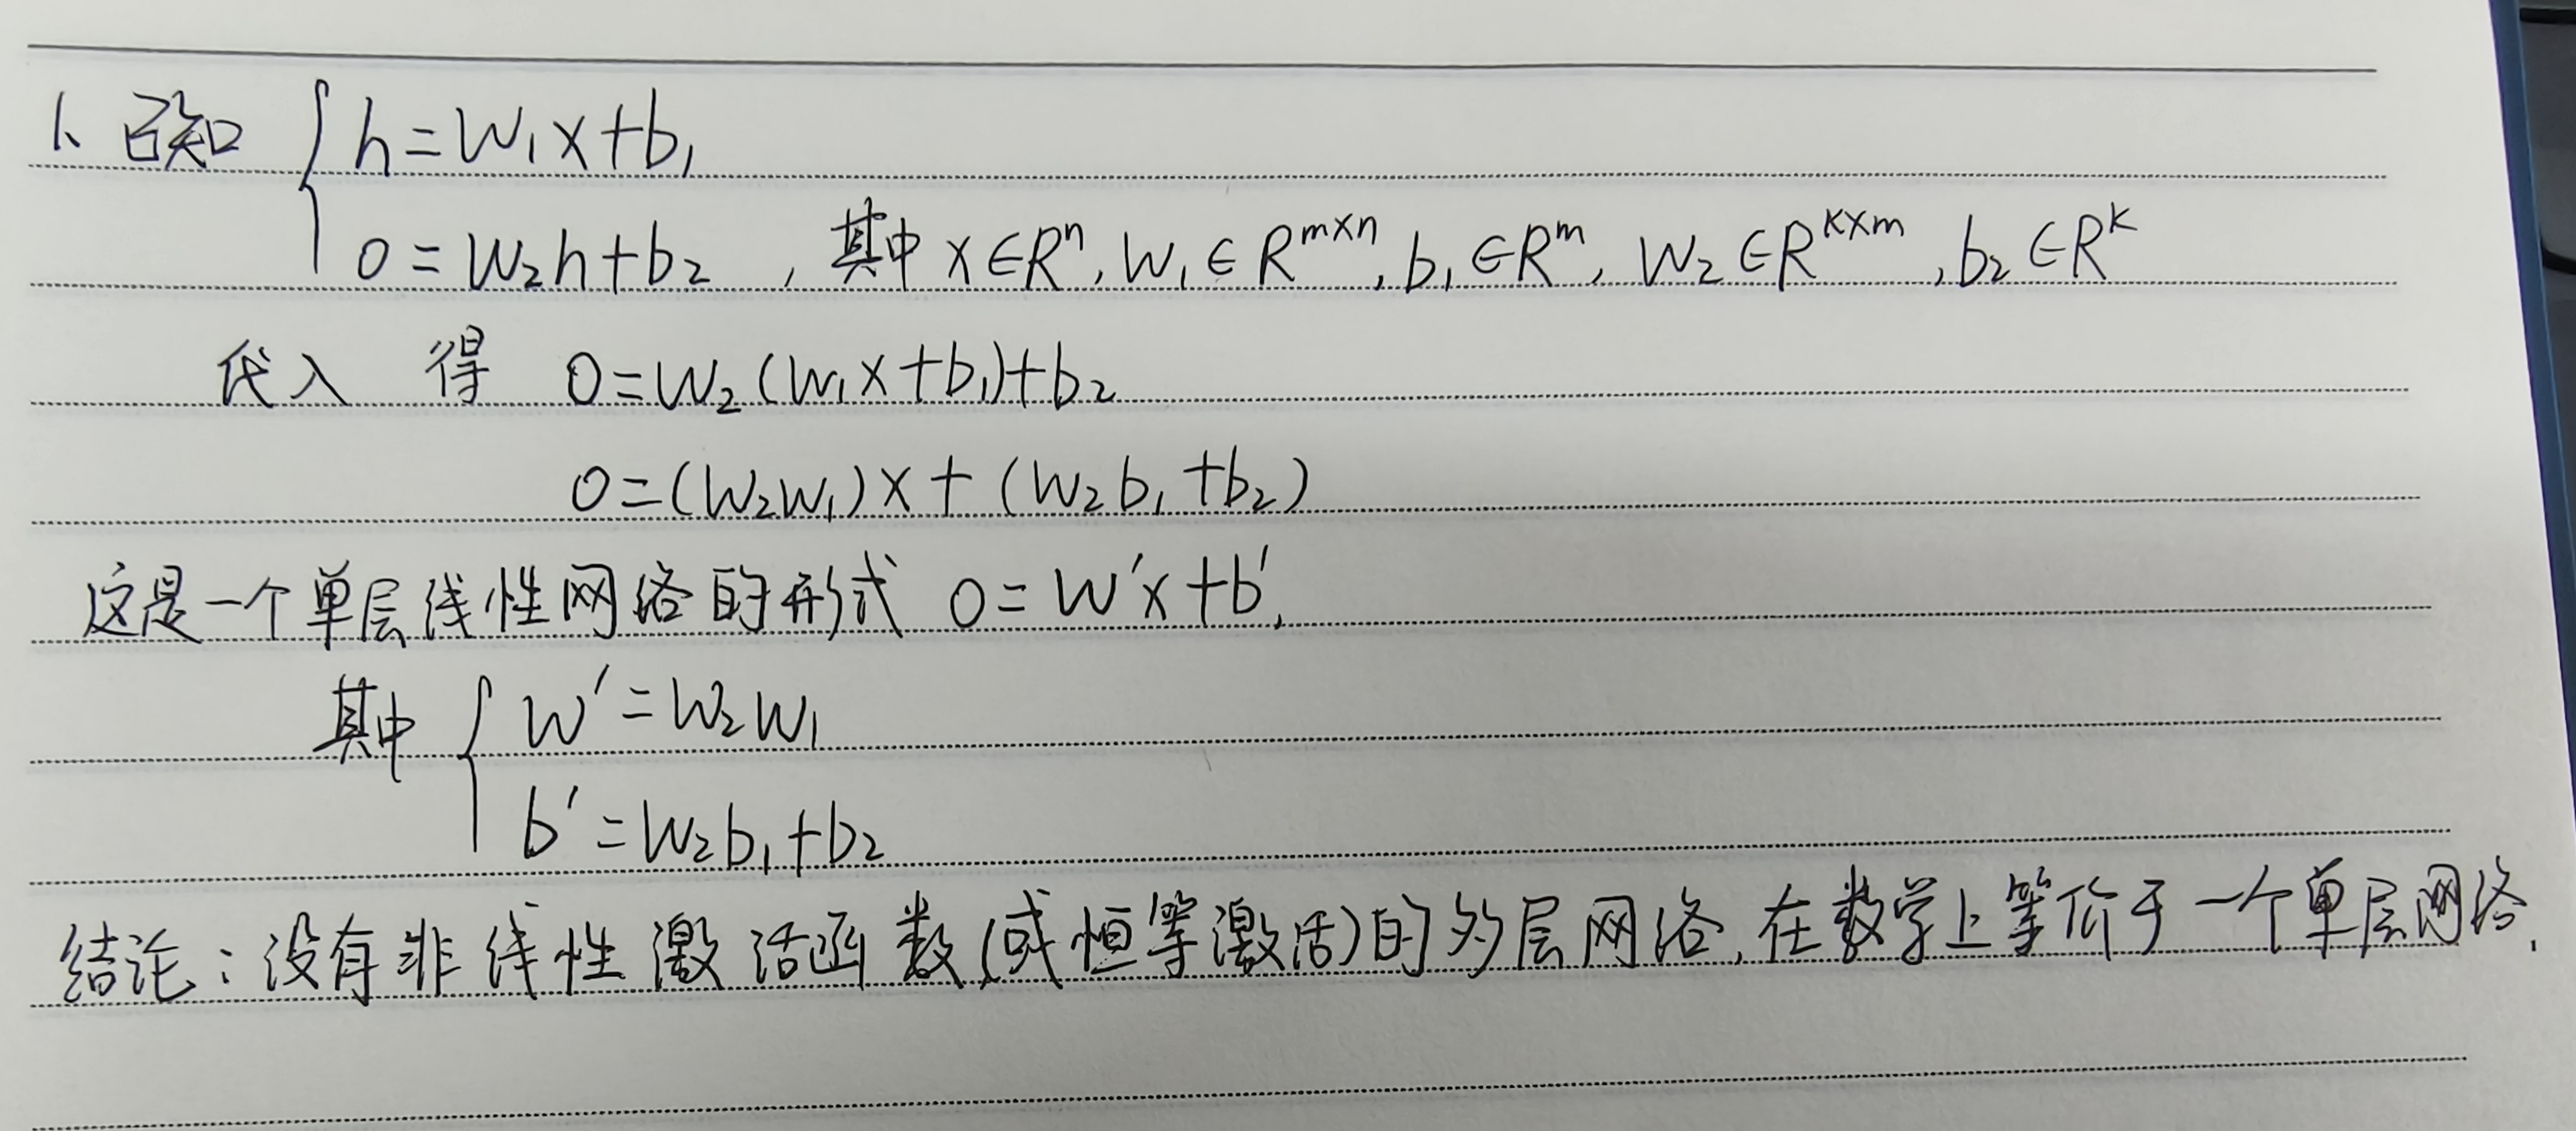

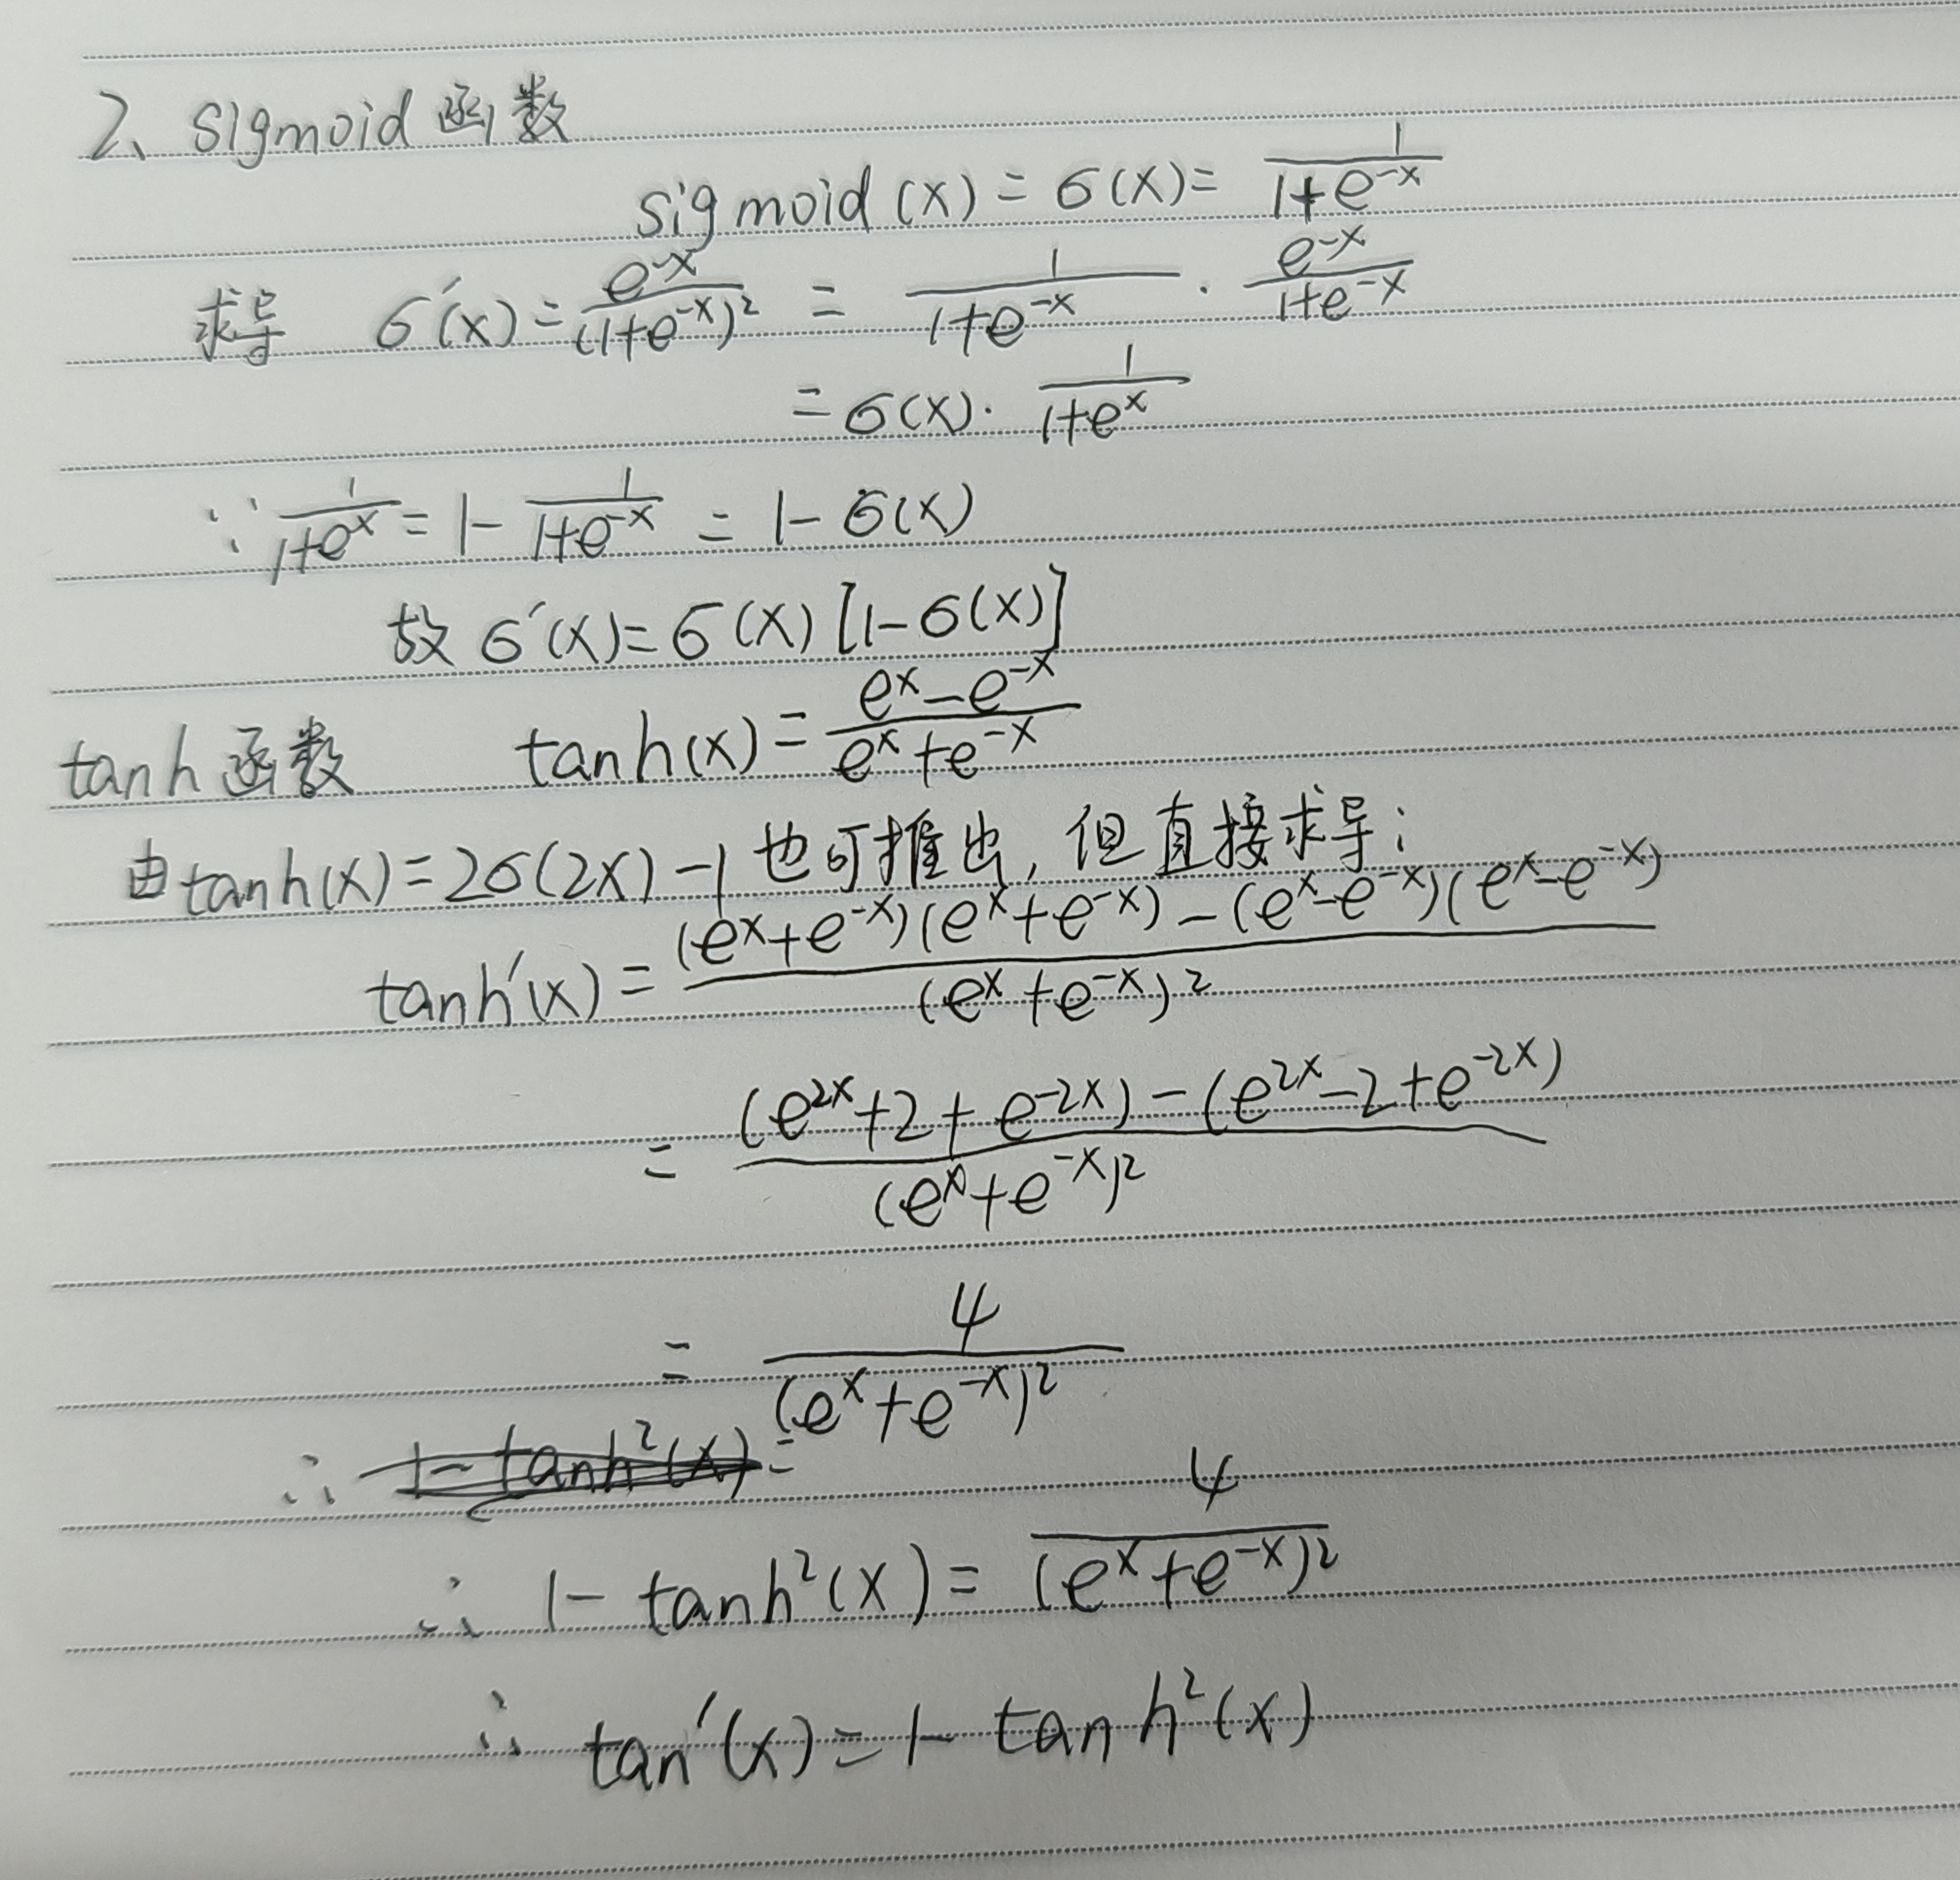

2.2编程题

2.2.1参数初始化

In [31]:
import numpy as np
import gzip
import os

# -------------------- 1. 下载并加载 Fashion-MNIST 数据（如果本地没有） --------------------
def load_fashion_mnist(data_path='./data'):
    """手动加载 Fashion-MNIST 二进制文件"""
    os.makedirs(data_path, exist_ok=True)
    
    # 下载链接
    base_url = 'http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/'
    files = {
        'train_images': 'train-images-idx3-ubyte.gz',
        'train_labels': 'train-labels-idx1-ubyte.gz',
        'test_images': 't10k-images-idx3-ubyte.gz',
        'test_labels': 't10k-labels-idx1-ubyte.gz'
    }
    
    # 检查并下载
    import urllib.request
    for name, fname in files.items():
        fpath = os.path.join(data_path, fname)
        if not os.path.exists(fpath):
            print(f"Downloading {fname}...")
            urllib.request.urlretrieve(base_url + fname, fpath)
    
    # 加载图像
    def load_images(filename):
        with gzip.open(os.path.join(data_path, filename), 'rb') as f:
            data = np.frombuffer(f.read(), np.uint8, offset=16)
        return data.reshape(-1, 784).astype(np.float32) / 255.0
    
    # 加载标签
    def load_labels(filename):
        with gzip.open(os.path.join(data_path, filename), 'rb') as f:
            return np.frombuffer(f.read(), np.uint8, offset=8)
    
    X_train = load_images('train-images-idx3-ubyte.gz')
    y_train = load_labels('train-labels-idx1-ubyte.gz')
    X_test = load_images('t10k-images-idx3-ubyte.gz')
    y_test = load_labels('t10k-labels-idx1-ubyte.gz')
    
    return X_train, y_train, X_test, y_test

print("Loading Fashion-MNIST...")
X_train, y_train, X_test, y_test = load_fashion_mnist()
print(f"Train: {X_train.shape}, {y_train.shape}")
print(f"Test: {X_test.shape}, {y_test.shape}")

# -------------------- 2. 小批量生成器 --------------------
def create_batches(X, y, batch_size):
    """生成小批量数据"""
    n_samples = X.shape[0]
    indices = np.random.permutation(n_samples)
    for i in range(0, n_samples, batch_size):
        batch_idx = indices[i:min(i+batch_size, n_samples)]
        yield X[batch_idx], y[batch_idx]

# -------------------- 3. 初始化参数（正态分布） --------------------
input_size = 784
hidden_size = 256
output_size = 10

# Xavier 初始化（正态分布，方差=1/输入维度）
W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
b1 = np.zeros(hidden_size)
W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)
b2 = np.zeros(output_size)


Loading Fashion-MNIST...
Train: (60000, 784), (60000,)
Test: (10000, 784), (10000,)


2.2.2实现ReLu激活函数

In [32]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    """ReLU 的导数（用于反向传播）"""
    return (x > 0).astype(float)


2.2.3实现带有Softmax的交叉熵损失函数

In [33]:
def softmax(x):
    """数值稳定的 softmax"""
    max_x = np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x - max_x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def cross_entropy_loss(probs, y):
    """计算交叉熵损失"""
    n_samples = probs.shape[0]
    correct_probs = probs[np.arange(n_samples), y]
    return -np.mean(np.log(correct_probs + 1e-8))

2.2.4训练循环+min-batch SGD

In [34]:
learning_rate = 0.1
batch_size = 64
epochs = 20

print("\n开始训练...")
for epoch in range(epochs):
    total_loss = 0
    correct = 0
    total = 0
    n_batches = 0
    
    # 打乱并遍历所有小批量
    for X_batch, y_batch in create_batches(X_train, y_train, batch_size):
        # ----- 前向传播 -----
        # 隐藏层
        z1 = np.dot(X_batch, W1) + b1          # [batch, hidden]
        a1 = relu(z1)
        
        # 输出层
        z2 = np.dot(a1, W2) + b2               # [batch, 10]
        probs = softmax(z2)
        
        # 计算损失
        loss = cross_entropy_loss(probs, y_batch)
        total_loss += loss
        
        # 计算准确率
        predictions = np.argmax(probs, axis=1)
        correct += np.sum(predictions == y_batch)
        total += len(y_batch)
        
        # ----- 反向传播（手动计算梯度）-----
        n = X_batch.shape[0]
        
        # 输出层梯度
        dz2 = probs.copy()
        dz2[np.arange(n), y_batch] -= 1
        dz2 /= n
        
        dW2 = np.dot(a1.T, dz2)
        db2 = np.sum(dz2, axis=0)
        
        # 隐藏层梯度
        da1 = np.dot(dz2, W2.T)
        dz1 = da1 * relu_derivative(z1)
        dW1 = np.dot(X_batch.T, dz1)
        db1 = np.sum(dz1, axis=0)
        
        # ----- 更新参数（SGD）-----
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1
        
        n_batches += 1
    
    avg_loss = total_loss / n_batches
    train_acc = correct / total * 100
    print(f"Epoch {epoch+1:2d}/{epochs} | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}%")

# -------------------- 7. 测试模型 --------------------
print("\n测试模型...")
correct = 0
total = 0

# 分批测试（避免内存不足）
batch_size_test = 128
for i in range(0, X_test.shape[0], batch_size_test):
    X_batch = X_test[i:min(i+batch_size_test, X_test.shape[0])]
    y_batch = y_test[i:min(i+batch_size_test, X_test.shape[0])]
    
    # 前向传播
    z1 = np.dot(X_batch, W1) + b1
    a1 = relu(z1)
    z2 = np.dot(a1, W2) + b2
    probs = softmax(z2)
    
    predictions = np.argmax(probs, axis=1)
    correct += np.sum(predictions == y_batch)
    total += len(y_batch)

test_acc = correct / total * 100
print(f"Test Accuracy: {test_acc:.2f}%")

# -------------------- 8. 展示几个预测示例 --------------------
print("\n示例预测（前10个测试样本）：")
sample_idx = np.arange(10)
X_sample = X_test[sample_idx]
y_true = y_test[sample_idx]

z1 = np.dot(X_sample, W1) + b1
a1 = relu(z1)
z2 = np.dot(a1, W2) + b2
probs = softmax(z2)
y_pred = np.argmax(probs, axis=1)

# Fashion-MNIST 类别名称
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

for i in range(10):
    print(f"True: {class_names[y_true[i]]:15s} | Pred: {class_names[y_pred[i]]:15s}")


开始训练...
Epoch  1/20 | Loss: 0.5730 | Train Acc: 80.06%
Epoch  2/20 | Loss: 0.4166 | Train Acc: 85.34%
Epoch  3/20 | Loss: 0.3759 | Train Acc: 86.48%
Epoch  4/20 | Loss: 0.3507 | Train Acc: 87.43%
Epoch  5/20 | Loss: 0.3324 | Train Acc: 87.96%
Epoch  6/20 | Loss: 0.3154 | Train Acc: 88.60%
Epoch  7/20 | Loss: 0.3026 | Train Acc: 89.02%
Epoch  8/20 | Loss: 0.2949 | Train Acc: 89.33%
Epoch  9/20 | Loss: 0.2849 | Train Acc: 89.55%
Epoch 10/20 | Loss: 0.2750 | Train Acc: 90.06%
Epoch 11/20 | Loss: 0.2696 | Train Acc: 90.19%
Epoch 12/20 | Loss: 0.2610 | Train Acc: 90.57%
Epoch 13/20 | Loss: 0.2542 | Train Acc: 90.67%
Epoch 14/20 | Loss: 0.2489 | Train Acc: 90.93%
Epoch 15/20 | Loss: 0.2419 | Train Acc: 91.16%
Epoch 16/20 | Loss: 0.2361 | Train Acc: 91.43%
Epoch 17/20 | Loss: 0.2324 | Train Acc: 91.53%
Epoch 18/20 | Loss: 0.2266 | Train Acc: 91.72%
Epoch 19/20 | Loss: 0.2202 | Train Acc: 91.91%
Epoch 20/20 | Loss: 0.2169 | Train Acc: 92.07%

测试模型...
Test Accuracy: 87.67%

示例预测（前10个测试样本）：
Tru

3.1理论题

3.1.1  训练误差极低但泛化误差很高，模型处于过拟合状态。

可以通过控制模型复杂度来缓解过拟合：

1、减少模型参数数量（降低隐藏层神经元个数、减少网络层数、特征选择）；

2、正则化；3、提前停止（监控验证集误差，当验证误差不再下降时提前终止训练）；

4、数据增强（增加训练数据多样性，简洁降低模型对特定样本的依赖）；

5、丢弃法：训练时随机“丢弃”一部分神经元，迫使模型学习冗余表示，防止单元间复杂共适应；

6、集成方法：Bagging、Boostiong等通过组合多个模型来降低方差。

3.1.2K折交叉验证

1、数据划分：将数据集D随机打乱后，均匀分割成K个互不相交的子集

2、循环训练与验证（i=1到K）：在训练集上训练模型，在验证集上Di上评估模型，记录性能指标score(如准确率、均方误差)

3、计算平均性能；

4、最终模型训练：如果需要部署最终模型，在全部数据上重新训练一次，或者基于交叉验证选择的最佳超惨重新训练

3.2理论题

3.2.权重衰减

In [35]:


# 重新初始化参数（使用相同的随机种子）
np.random.seed(42)
W1_wd = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
b1_wd = np.zeros(hidden_size)
W2_wd = np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)
b2_wd = np.zeros(output_size)

# 权重衰减超参数
weight_decay = 0.0005  # 权重衰减系数 λ

print(f"\n开始训练带权重衰减版本 (λ = {weight_decay})...")
print(f"更新公式: W = W * (1 - ηλ) - η * dW")

for epoch in range(epochs):
    total_loss = 0
    correct = 0
    total = 0
    n_batches = 0
    
    for X_batch, y_batch in create_batches(X_train, y_train, batch_size):
        # 前向传播
        z1 = np.dot(X_batch, W1_wd) + b1_wd
        a1 = relu(z1)
        z2 = np.dot(a1, W2_wd) + b2_wd
        probs = softmax(z2)
        
        # 计算损失（仅交叉熵，用于监控）
        loss = cross_entropy_loss(probs, y_batch)
        total_loss += loss
        
        # 计算准确率
        predictions = np.argmax(probs, axis=1)
        correct += np.sum(predictions == y_batch)
        total += len(y_batch)
        
        # 反向传播
        n = X_batch.shape[0]
        
        dz2 = probs.copy()
        dz2[np.arange(n), y_batch] -= 1
        dz2 /= n
        
        dW2 = np.dot(a1.T, dz2)
        db2 = np.sum(dz2, axis=0)
        
        da1 = np.dot(dz2, W2_wd.T)
        dz1 = da1 * relu_derivative(z1)
        dW1 = np.dot(X_batch.T, dz1)
        db1 = np.sum(dz1, axis=0)
        
        # 带权重衰减的参数更新
        W2_wd = W2_wd * (1 - learning_rate * weight_decay) - learning_rate * dW2
        b2_wd -= learning_rate * db2
        
        W1_wd = W1_wd * (1 - learning_rate * weight_decay) - learning_rate * dW1
        b1_wd -= learning_rate * db1
        
        n_batches += 1
    
    avg_loss = total_loss / n_batches
    train_acc = correct / total * 100
    
    # 计算权重范数
    weight_norm = np.sqrt(np.sum(W1_wd**2) + np.sum(W2_wd**2))
    
    print(f"Epoch {epoch+1:2d}/{epochs} | Loss: {avg_loss:.4f} | "
          f"Train Acc: {train_acc:.2f}% | Weight Norm: {weight_norm:.4f}")

# 测试权重衰减版本
print("\n测试带权重衰减版本...")
correct = 0
total = 0

for i in range(0, X_test.shape[0], batch_size_test):
    X_batch = X_test[i:min(i+batch_size_test, X_test.shape[0])]
    y_batch = y_test[i:min(i+batch_size_test, X_test.shape[0])]
    
    z1 = np.dot(X_batch, W1_wd) + b1_wd
    a1 = relu(z1)
    z2 = np.dot(a1, W2_wd) + b2_wd
    probs = softmax(z2)
    
    predictions = np.argmax(probs, axis=1)
    correct += np.sum(predictions == y_batch)
    total += len(y_batch)

test_acc_weight_decay = correct / total * 100
print(f"权重衰减版本测试准确率: {test_acc_weight_decay:.2f}%")

# 展示权重衰减版本的预测示例
print("\n权重衰减版本示例预测（前10个测试样本）：")
z1 = np.dot(X_sample, W1_wd) + b1_wd
a1 = relu(z1)
z2 = np.dot(a1, W2_wd) + b2_wd
probs = softmax(z2)
y_pred_wd = np.argmax(probs, axis=1)

for i in range(10):
    print(f"True: {class_names[y_true[i]]:15s} | Pred: {class_names[y_pred_wd[i]]:15s}")

# 运行原始版本并对比 
print("\n" + "="*60)
print("第三部分：训练原始版本（无权重衰减）用于对比")
print("="*60)

# 重新初始化原始参数（相同随机种子）
np.random.seed(42)
W1_orig = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
b1_orig = np.zeros(hidden_size)
W2_orig = np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)
b2_orig = np.zeros(output_size)

print("\n开始训练原始版本...")

for epoch in range(epochs):
    total_loss = 0
    correct = 0
    total = 0
    n_batches = 0
    
    for X_batch, y_batch in create_batches(X_train, y_train, batch_size):
        # 前向传播
        z1 = np.dot(X_batch, W1_orig) + b1_orig
        a1 = relu(z1)
        z2 = np.dot(a1, W2_orig) + b2_orig
        probs = softmax(z2)
        
        # 计算损失
        loss = cross_entropy_loss(probs, y_batch)
        total_loss += loss
        
        # 计算准确率
        predictions = np.argmax(probs, axis=1)
        correct += np.sum(predictions == y_batch)
        total += len(y_batch)
        
        # 反向传播
        n = X_batch.shape[0]
        
        dz2 = probs.copy()
        dz2[np.arange(n), y_batch] -= 1
        dz2 /= n
        
        dW2 = np.dot(a1.T, dz2)
        db2 = np.sum(dz2, axis=0)
        
        da1 = np.dot(dz2, W2_orig.T)
        dz1 = da1 * relu_derivative(z1)
        dW1 = np.dot(X_batch.T, dz1)
        db1 = np.sum(dz1, axis=0)
        
        # 原始参数更新（无权重衰减）
        W2_orig -= learning_rate * dW2
        b2_orig -= learning_rate * db2
        W1_orig -= learning_rate * dW1
        b1_orig -= learning_rate * db1
        
        n_batches += 1
    
    avg_loss = total_loss / n_batches
    train_acc = correct / total * 100
    
    # 计算权重范数
    weight_norm = np.sqrt(np.sum(W1_orig**2) + np.sum(W2_orig**2))
    
    print(f"Epoch {epoch+1:2d}/{epochs} | Loss: {avg_loss:.4f} | "
          f"Train Acc: {train_acc:.2f}% | Weight Norm: {weight_norm:.4f}")

# 测试原始版本
print("\n测试原始版本...")
correct = 0
total = 0

for i in range(0, X_test.shape[0], batch_size_test):
    X_batch = X_test[i:min(i+batch_size_test, X_test.shape[0])]
    y_batch = y_test[i:min(i+batch_size_test, X_test.shape[0])]
    
    z1 = np.dot(X_batch, W1_orig) + b1_orig
    a1 = relu(z1)
    z2 = np.dot(a1, W2_orig) + b2_orig
    probs = softmax(z2)
    
    predictions = np.argmax(probs, axis=1)
    correct += np.sum(predictions == y_batch)
    total += len(y_batch)

test_acc_original = correct / total * 100
print(f"原始版本测试准确率: {test_acc_original:.2f}%")

# 展示原始版本的预测示例
print("\n原始版本示例预测（前10个测试样本）：")
z1 = np.dot(X_sample, W1_orig) + b1_orig
a1 = relu(z1)
z2 = np.dot(a1, W2_orig) + b2_orig
probs = softmax(z2)
y_pred_orig = np.argmax(probs, axis=1)

for i in range(10):
    print(f"True: {class_names[y_true[i]]:15s} | Pred: {class_names[y_pred_orig[i]]:15s}")

#  第四部分：对比总结 ====================
print("\n" + "="*60)
print("对比总结")
print("="*60)
print(f"原始版本测试准确率:        {test_acc_original:.2f}%")
print(f"带权重衰减版本测试准确率:  {test_acc_weight_decay:.2f}%")
print(f"准确率差异:               {test_acc_weight_decay - test_acc_original:+.2f}%")

# 分析哪个版本更好
if test_acc_weight_decay > test_acc_original:
    improvement = test_acc_weight_decay - test_acc_original
    print(f"\n✓ 权重衰减提升了 {improvement:.2f}% 的准确率！")
    print("  权重衰减成功防止了过拟合，提高了泛化能力。")
elif test_acc_weight_decay < test_acc_original:
    decrease = test_acc_original - test_acc_weight_decay
    print(f"\n✗ 权重衰减导致准确率下降了 {decrease:.2f}%")
    print("  可能原因：权重衰减系数过大，或模型本身没有过拟合。")
else:
    print("\n两个版本准确率相同")

print("\n权重衰减的作用：")
print("1. 限制权重的增长，防止过拟合")
print("2. 提高模型的泛化能力")  
print("3. 鼓励学习更简单的特征表示")
print("\n建议调整的权重衰减值：")
print("- 如果过拟合严重：尝试 λ = 0.001 ~ 0.01")
print("- 如果欠拟合：尝试 λ = 0.0001 或更小")
print("- Fashion-MNIST 推荐：λ = 0.0005")

# 计算并显示权重范数对比
print("\n" + "="*60)
print("权重范数对比")
print("="*60)
W1_norm_orig = np.sqrt(np.sum(W1_orig**2))
W2_norm_orig = np.sqrt(np.sum(W2_orig**2))
W1_norm_wd = np.sqrt(np.sum(W1_wd**2))
W2_norm_wd = np.sqrt(np.sum(W2_wd**2))

print(f"原始版本 - W1范数: {W1_norm_orig:.4f}, W2范数: {W2_norm_orig:.4f}")
print(f"权重衰减版本 - W1范数: {W1_norm_wd:.4f}, W2范数: {W2_norm_wd:.4f}")
print(f"W1范数减少: {(W1_norm_orig - W1_norm_wd):.4f}")
print(f"W2范数减少: {(W2_norm_orig - W2_norm_wd):.4f}")


开始训练带权重衰减版本 (λ = 0.0005)...
更新公式: W = W * (1 - ηλ) - η * dW
Epoch  1/20 | Loss: 0.5747 | Train Acc: 80.01% | Weight Norm: 23.0394
Epoch  2/20 | Loss: 0.4214 | Train Acc: 85.08% | Weight Norm: 22.6226
Epoch  3/20 | Loss: 0.3836 | Train Acc: 86.22% | Weight Norm: 22.1875
Epoch  4/20 | Loss: 0.3607 | Train Acc: 87.08% | Weight Norm: 21.7559
Epoch  5/20 | Loss: 0.3437 | Train Acc: 87.61% | Weight Norm: 21.3509
Epoch  6/20 | Loss: 0.3305 | Train Acc: 88.05% | Weight Norm: 20.9769
Epoch  7/20 | Loss: 0.3206 | Train Acc: 88.40% | Weight Norm: 20.6335
Epoch  8/20 | Loss: 0.3116 | Train Acc: 88.75% | Weight Norm: 20.3165
Epoch  9/20 | Loss: 0.3044 | Train Acc: 89.02% | Weight Norm: 20.0409
Epoch 10/20 | Loss: 0.2973 | Train Acc: 89.33% | Weight Norm: 19.7758
Epoch 11/20 | Loss: 0.2918 | Train Acc: 89.42% | Weight Norm: 19.5449
Epoch 12/20 | Loss: 0.2857 | Train Acc: 89.67% | Weight Norm: 19.3548
Epoch 13/20 | Loss: 0.2807 | Train Acc: 89.95% | Weight Norm: 19.1790
Epoch 14/20 | Loss: 0.2770 | 

3.2.2Dropout 从零实现

In [36]:
def dropout_layer(X, dropout_prob, is_training=True):
    """
    Dropout层实现
    
    参数:
    X: 输入张量 (任意形状)
    dropout_prob: 丢弃概率 p (0 <= p < 1)
    is_training: 是否为训练模式（训练时启用dropout，测试时关闭）
    
    返回:
    输出张量和掩码（便于调试）
    """
    if not is_training or dropout_prob == 0:
        # 测试模式或丢弃概率为0：直接返回原值
        return X, None
    
    # 保留概率
    keep_prob = 1 - dropout_prob
    
    # 生成随机掩码：伯努利分布，以 keep_prob 的概率保留元素
    mask = np.random.binomial(1, keep_prob, size=X.shape) > 0
    mask = mask.astype(float)
    
    # 应用掩码（丢弃的元素置0）并缩放
    # 缩放因子：1/keep_prob 保持期望值不变
    output = X * mask / keep_prob
    
    return output, mask

# 测试Dropout层的基本功能
print("\n1. 测试Dropout层基本功能：")
test_input = np.array([[1, 2, 3, 4, 5, 6, 7, 8]])
dropout_prob = 0.3
print(f"输入: {test_input}")
print(f"丢弃概率: {dropout_prob}")

# 训练模式
output_train, mask_train = dropout_layer(test_input, dropout_prob, is_training=True)
print(f"\n训练模式输出: {output_train}")
print(f"掩码 (1保留, 0丢弃): {mask_train}")
print(f"掩码保留比例: {np.mean(mask_train):.2f} (期望保留: {1-dropout_prob})")

# 测试模式
output_test, _ = dropout_layer(test_input, dropout_prob, is_training=False)
print(f"\n测试模式输出: {output_test}")
print(f"测试模式输出与原输入相同: {np.array_equal(output_test, test_input)}")

# 验证期望值不变
print("\n2. 验证期望值不变（多次实验）：")
n_trials = 1000
test_input_multi = np.ones((100, 10))  # 全1输入
outputs = []

for _ in range(n_trials):
    out, _ = dropout_layer(test_input_multi, dropout_prob=0.3, is_training=True)
    outputs.append(np.mean(out))

print(f"理论期望值: {np.mean(test_input_multi)}")
print(f"实际均值: {np.mean(outputs):.4f}")
print(f"误差: {abs(np.mean(outputs) - np.mean(test_input_multi)):.4f}")

# ==================== 第六部分：在完整模型中使用Dropout ====================
print("\n" + "="*60)
print("第六部分：在完整模型中使用Dropout")
print("="*60)

# 重新初始化参数
np.random.seed(42)
W1_dropout = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
b1_dropout = np.zeros(hidden_size)
W2_dropout = np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)
b2_dropout = np.zeros(output_size)

# Dropout超参数
dropout_prob = 0.5  # 隐藏层Dropout概率
learning_rate = 0.1
batch_size = 64
epochs = 20

print(f"\n开始训练带Dropout版本 (dropout_prob = {dropout_prob})...")
print("注：Dropout仅在训练时启用，测试时自动禁用")

train_losses_dropout = []
train_accs_dropout = []

for epoch in range(epochs):
    total_loss = 0
    correct = 0
    total = 0
    n_batches = 0
    
    for X_batch, y_batch in create_batches(X_train, y_train, batch_size):
        # ----- 前向传播（训练模式，启用Dropout）-----
        # 隐藏层
        z1 = np.dot(X_batch, W1_dropout) + b1_dropout
        a1 = relu(z1)
        
        # 对隐藏层输出应用Dropout（训练模式）
        a1_dropout, mask_hidden = dropout_layer(a1, dropout_prob, is_training=True)
        
        # 输出层
        z2 = np.dot(a1_dropout, W2_dropout) + b2_dropout
        probs = softmax(z2)
        
        # 计算损失
        loss = cross_entropy_loss(probs, y_batch)
        total_loss += loss
        
        # 计算准确率（用于监控）
        predictions = np.argmax(probs, axis=1)
        correct += np.sum(predictions == y_batch)
        total += len(y_batch)
        
        # ----- 反向传播（注意：Dropout层的梯度传播）-----
        n = X_batch.shape[0]
        
        # 输出层梯度
        dz2 = probs.copy()
        dz2[np.arange(n), y_batch] -= 1
        dz2 /= n
        
        dW2 = np.dot(a1_dropout.T, dz2)
        db2 = np.sum(dz2, axis=0)
        
        # 传播到Dropout层之前
        da1_dropout = np.dot(dz2, W2_dropout.T)
        
        # 通过Dropout层的反向传播
        # 梯度需要乘以掩码并除以keep_prob（因为前向传播进行了缩放）
        keep_prob = 1 - dropout_prob
        if keep_prob > 0:
            da1 = da1_dropout * mask_hidden / keep_prob
        else:
            da1 = np.zeros_like(da1_dropout)
        
        # 通过ReLU激活函数
        dz1 = da1 * relu_derivative(z1)
        
        # 隐藏层权重梯度
        dW1 = np.dot(X_batch.T, dz1)
        db1 = np.sum(dz1, axis=0)
        
        # 更新参数
        W2_dropout -= learning_rate * dW2
        b2_dropout -= learning_rate * db2
        W1_dropout -= learning_rate * dW1
        b1_dropout -= learning_rate * db1
        
        n_batches += 1
    
    avg_loss = total_loss / n_batches
    train_acc = correct / total * 100
    train_losses_dropout.append(avg_loss)
    train_accs_dropout.append(train_acc)
    
    print(f"Epoch {epoch+1:2d}/{epochs} | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}%")

# 测试Dropout版本（测试模式自动禁用Dropout）
print("\n测试带Dropout版本...")
correct = 0
total = 0

for i in range(0, X_test.shape[0], batch_size_test):
    X_batch = X_test[i:min(i+batch_size_test, X_test.shape[0])]
    y_batch = y_test[i:min(i+batch_size_test, X_test.shape[0])]
    
    # 测试时，dropout层自动禁用（is_training=False）
    z1 = np.dot(X_batch, W1_dropout) + b1_dropout
    a1 = relu(z1)
    a1_dropout, _ = dropout_layer(a1, dropout_prob, is_training=False)  # 测试模式
    z2 = np.dot(a1_dropout, W2_dropout) + b2_dropout
    probs = softmax(z2)
    
    predictions = np.argmax(probs, axis=1)
    correct += np.sum(predictions == y_batch)
    total += len(y_batch)

test_acc_dropout = correct / total * 100
print(f"Dropout版本测试准确率: {test_acc_dropout:.2f}%")

# 展示Dropout版本的预测示例
print("\nDropout版本示例预测（前10个测试样本）：")
z1 = np.dot(X_sample, W1_dropout) + b1_dropout
a1 = relu(z1)
a1_dropout, _ = dropout_layer(a1, dropout_prob, is_training=False)
z2 = np.dot(a1_dropout, W2_dropout) + b2_dropout
probs = softmax(z2)
y_pred_dropout = np.argmax(probs, axis=1)

for i in range(10):
    print(f"True: {class_names[y_true[i]]:15s} | Pred: {class_names[y_pred_dropout[i]]:15s}")

# ==================== 第七部分：综合分析对比 ====================
print("\n" + "="*60)
print("第七部分：三个版本综合分析对比")
print("="*60)

print(f"{'版本':<20} {'测试准确率':<15} {'特点'}")
print("-" * 60)
print(f"{'原始版本':<20} {test_acc_original:>8.2f}%      {'无正则化'}")
print(f"{'权重衰减版本':<20} {test_acc_weight_decay:>8.2f}%      {'L2正则化 (λ=0.0005)'}")
print(f"{'Dropout版本':<20} {test_acc_dropout:>8.2f}%      {'Dropout (p=0.5)'}")

# 找出最佳版本
accuracies = {
    '原始版本': test_acc_original,
    '权重衰减': test_acc_weight_decay,
    'Dropout': test_acc_dropout
}
best_version = max(accuracies, key=accuracies.get)
print(f"\n🏆 最佳版本: {best_version} (准确率: {accuracies[best_version]:.2f}%)")

# Dropout效果分析
print("\n" + "="*60)
print("Dropout 原理解析")
print("="*60)
print("1. 作用机制：")
print("   - 在训练时随机丢弃一部分神经元（设为0）")
print("   - 避免神经元之间产生复杂的共适应关系")
print("   - 相当于训练多个子网络的集成")

print("\n2. 缩放技巧：")
print("   - 训练时：output = X * mask / keep_prob")
print("   - 测试时：output = X（不做任何处理）")
print("   - 目的：保持训练和测试时输出的期望值一致")

print("\n3. 超参数选择建议：")
print("   - 隐藏层：p = 0.5 是常见选择")
print("   - 输入层：p = 0.2 (较小的丢弃概率)")
print("   - 如果过拟合严重：增加 p")
print("   - 如果欠拟合：减小 p 或关闭 Dropout")

print("\n4. Dropout vs 权重衰减：")
print("   - Dropout：随机丢弃神经元，增强鲁棒性")
print("   - 权重衰减：限制权重大小，防止过拟合")
print("   - 可以同时使用两种正则化技术")




1. 测试Dropout层基本功能：
输入: [[1 2 3 4 5 6 7 8]]
丢弃概率: 0.3

训练模式输出: [[ 0.          2.85714286  4.28571429  5.71428571  7.14285714  8.57142857
  10.         11.42857143]]
掩码 (1保留, 0丢弃): [[0. 1. 1. 1. 1. 1. 1. 1.]]
掩码保留比例: 0.88 (期望保留: 0.7)

测试模式输出: [[1 2 3 4 5 6 7 8]]
测试模式输出与原输入相同: True

2. 验证期望值不变（多次实验）：
理论期望值: 1.0
实际均值: 1.0008
误差: 0.0008

第六部分：在完整模型中使用Dropout

开始训练带Dropout版本 (dropout_prob = 0.5)...
注：Dropout仅在训练时启用，测试时自动禁用
Epoch  1/20 | Loss: 0.6464 | Train Acc: 77.26%
Epoch  2/20 | Loss: 0.4806 | Train Acc: 82.93%
Epoch  3/20 | Loss: 0.4395 | Train Acc: 84.16%
Epoch  4/20 | Loss: 0.4170 | Train Acc: 84.92%
Epoch  5/20 | Loss: 0.3987 | Train Acc: 85.66%
Epoch  6/20 | Loss: 0.3860 | Train Acc: 86.13%
Epoch  7/20 | Loss: 0.3763 | Train Acc: 86.42%
Epoch  8/20 | Loss: 0.3644 | Train Acc: 86.58%
Epoch  9/20 | Loss: 0.3576 | Train Acc: 86.93%
Epoch 10/20 | Loss: 0.3525 | Train Acc: 87.26%
Epoch 11/20 | Loss: 0.3457 | Train Acc: 87.41%
Epoch 12/20 | Loss: 0.3399 | Train Acc: 87.65%
Epoch 13/20 | 

3.2.3对比实验

In [37]:
# ==================== 完整的对比实验（可直接运行） ====================
import numpy as np

print("\n" + "="*80)
print("完整的正则化对比实验 - 高维多项式拟合")
print("="*80)

# 生成高维多项式数据集（带噪声）
np.random.seed(42)
n_samples = 150
n_test_samples = 500
n_features = 50  # 高维特征

# 生成真实参数（稀疏的）
true_params = np.random.randn(n_features) * 0.5
true_params[10:] = 0  # 只有前10个特征有用

# 训练集（少量数据，容易过拟合）
X_train_poly = np.random.randn(n_samples, n_features)
y_train_poly = (X_train_poly @ true_params + 0.2 * np.random.randn(n_samples))

# 测试集（大量数据，用于验证泛化能力）
X_test_poly = np.random.randn(n_test_samples, n_features)
y_test_poly = (X_test_poly @ true_params + 0.2 * np.random.randn(n_test_samples))

# 数据标准化
def normalize_data(X_train, X_test):
    mean = np.mean(X_train, axis=0)
    std = np.std(X_train, axis=0)
    std[std == 0] = 1
    X_train_norm = (X_train - mean) / std
    X_test_norm = (X_test - mean) / std
    return X_train_norm, X_test_norm

X_train_poly, X_test_poly = normalize_data(X_train_poly, X_test_poly)

print(f"数据集信息：")
print(f"  训练样本数: {n_samples}")
print(f"  测试样本数: {n_test_samples}")
print(f"  特征维度: {n_features}")
print(f"  有效特征数: {np.sum(true_params != 0)}")

# 定义ComplexMLP类
class ComplexMLP:
    """复杂MLP模型，用于展示过拟合"""
    def __init__(self, input_dim, hidden_dims, output_dim=1, dropout_prob=0.0, weight_decay=0.0):
        self.input_dim = input_dim
        self.hidden_dims = hidden_dims
        self.output_dim = output_dim
        self.dropout_prob = dropout_prob
        self.weight_decay = weight_decay
        
        # 初始化权重和偏置
        self.W = []
        self.b = []
        
        prev_dim = input_dim
        for i, hidden_dim in enumerate(hidden_dims):
            # Xavier初始化
            self.W.append(np.random.randn(prev_dim, hidden_dim) * np.sqrt(2.0 / prev_dim))
            self.b.append(np.zeros(hidden_dim))
            prev_dim = hidden_dim
        
        # 输出层
        self.W.append(np.random.randn(prev_dim, output_dim) * np.sqrt(2.0 / prev_dim))
        self.b.append(np.zeros(output_dim))
        
    def forward(self, X, is_training=True, return_masks=False):
        """前向传播"""
        self.cache = {}
        self.masks = []
        current = X
        
        for i in range(len(self.W) - 1):
            z = np.dot(current, self.W[i]) + self.b[i]
            self.cache[f'z{i}'] = z
            
            a = np.maximum(0, z)
            self.cache[f'a{i}'] = a
            
            if self.dropout_prob > 0 and is_training:
                keep_prob = 1 - self.dropout_prob
                mask = np.random.binomial(1, keep_prob, size=a.shape) / keep_prob
                a = a * mask
                self.masks.append(mask)
            else:
                self.masks.append(None)
            
            current = a
        
        z_out = np.dot(current, self.W[-1]) + self.b[-1]
        self.cache['z_out'] = z_out
        
        if return_masks:
            return z_out, self.masks
        return z_out
    
    def backward(self, X, y, learning_rate):
        """反向传播"""
        n_samples = X.shape[0]
        
        dz_out = self.cache['z_out'] - y.reshape(-1, 1)
        dW_out = np.dot(self.cache[f'a{len(self.W)-2}'].T, dz_out) / n_samples
        db_out = np.sum(dz_out, axis=0) / n_samples
        
        self.W[-1] -= learning_rate * (dW_out + self.weight_decay * self.W[-1])
        self.b[-1] -= learning_rate * db_out
        
        dz = dz_out
        
        for i in range(len(self.W) - 2, -1, -1):
            if self.dropout_prob > 0 and self.masks[i] is not None:
                dz = dz * self.masks[i]
            
            da = dz
            dz = da * (self.cache[f'z{i}'] > 0).astype(float)
            
            prev_activation = X if i == 0 else self.cache[f'a{i-1}']
            dW = np.dot(prev_activation.T, dz) / n_samples
            db = np.sum(dz, axis=0) / n_samples
            
            self.W[i] -= learning_rate * (dW + self.weight_decay * self.W[i])
            self.b[i] -= learning_rate * db
            
            dz = np.dot(dz, self.W[i].T)
    
    def compute_loss(self, y_pred, y_true):
        return np.mean((y_pred.flatten() - y_true) ** 2)

# 训练配置
hidden_layers = [128, 64, 32]
learning_rate = 0.01
epochs = 300  # 减少到300轮以加快速度
batch_size = 32

# 计算参数量
total_params = (n_features * hidden_layers[0] + hidden_layers[0] +
                hidden_layers[0] * hidden_layers[1] + hidden_layers[1] +
                hidden_layers[1] * hidden_layers[2] + hidden_layers[2] +
                hidden_layers[2] * 1 + 1)

print(f"\n模型配置：")
print(f"  输入维度: {n_features}")
print(f"  隐藏层结构: {hidden_layers}")
print(f"  总参数量: {total_params}")
print(f"  训练轮数: {epochs}")

# ==================== 1. 无正则化 ====================
print("\n" + "-"*60)
print("1. 训练无正则化模型...")
print("-"*60)

np.random.seed(42)
model_no_reg = ComplexMLP(
    input_dim=n_features,
    hidden_dims=hidden_layers,
    output_dim=1,
    dropout_prob=0.0,
    weight_decay=0.0
)

train_losses_no_reg = []
test_losses_no_reg = []

for epoch in range(epochs):
    indices = np.random.permutation(len(X_train_poly))
    epoch_train_loss = 0
    n_batches = 0
    
    for i in range(0, len(X_train_poly), batch_size):
        batch_idx = indices[i:i+batch_size]
        X_batch = X_train_poly[batch_idx]
        y_batch = y_train_poly[batch_idx]
        
        y_pred = model_no_reg.forward(X_batch, is_training=True)
        loss = model_no_reg.compute_loss(y_pred, y_batch)
        epoch_train_loss += loss
        
        model_no_reg.backward(X_batch, y_batch, learning_rate)
        n_batches += 1
    
    avg_train_loss = epoch_train_loss / n_batches
    train_losses_no_reg.append(avg_train_loss)
    
    y_pred_test = model_no_reg.forward(X_test_poly, is_training=False)
    test_loss = model_no_reg.compute_loss(y_pred_test, y_test_poly)
    test_losses_no_reg.append(test_loss)
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:3d}/{epochs} | Train Loss: {avg_train_loss:.6f} | Test Loss: {test_loss:.6f}")

# ==================== 2. 权重衰减 ====================
print("\n" + "-"*60)
print("2. 训练权重衰减模型 (λ=0.01)...")
print("-"*60)

np.random.seed(42)
model_wd = ComplexMLP(
    input_dim=n_features,
    hidden_dims=hidden_layers,
    output_dim=1,
    dropout_prob=0.0,
    weight_decay=0.01
)

train_losses_wd = []
test_losses_wd = []

for epoch in range(epochs):
    indices = np.random.permutation(len(X_train_poly))
    epoch_train_loss = 0
    n_batches = 0
    
    for i in range(0, len(X_train_poly), batch_size):
        batch_idx = indices[i:i+batch_size]
        X_batch = X_train_poly[batch_idx]
        y_batch = y_train_poly[batch_idx]
        
        y_pred = model_wd.forward(X_batch, is_training=True)
        loss = model_wd.compute_loss(y_pred, y_batch)
        epoch_train_loss += loss
        
        model_wd.backward(X_batch, y_batch, learning_rate)
        n_batches += 1
    
    avg_train_loss = epoch_train_loss / n_batches
    train_losses_wd.append(avg_train_loss)
    
    y_pred_test = model_wd.forward(X_test_poly, is_training=False)
    test_loss = model_wd.compute_loss(y_pred_test, y_test_poly)
    test_losses_wd.append(test_loss)
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:3d}/{epochs} | Train Loss: {avg_train_loss:.6f} | Test Loss: {test_loss:.6f}")

# ==================== 3. Dropout ====================
print("\n" + "-"*60)
print("3. 训练Dropout模型 (dropout_prob=0.5)...")
print("-"*60)

np.random.seed(42)
model_dropout = ComplexMLP(
    input_dim=n_features,
    hidden_dims=hidden_layers,
    output_dim=1,
    dropout_prob=0.5,
    weight_decay=0.0
)

train_losses_dropout = []
test_losses_dropout = []

for epoch in range(epochs):
    indices = np.random.permutation(len(X_train_poly))
    epoch_train_loss = 0
    n_batches = 0
    
    for i in range(0, len(X_train_poly), batch_size):
        batch_idx = indices[i:i+batch_size]
        X_batch = X_train_poly[batch_idx]
        y_batch = y_train_poly[batch_idx]
        
        y_pred = model_dropout.forward(X_batch, is_training=True)
        loss = model_dropout.compute_loss(y_pred, y_batch)
        epoch_train_loss += loss
        
        model_dropout.backward(X_batch, y_batch, learning_rate)
        n_batches += 1
    
    avg_train_loss = epoch_train_loss / n_batches
    train_losses_dropout.append(avg_train_loss)
    
    y_pred_test = model_dropout.forward(X_test_poly, is_training=False)
    test_loss = model_dropout.compute_loss(y_pred_test, y_test_poly)
    test_losses_dropout.append(test_loss)
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:3d}/{epochs} | Train Loss: {avg_train_loss:.6f} | Test Loss: {test_loss:.6f}")

# ==================== 显示详细结果 ====================
print("\n" + "="*80)
print("实验结果详细分析")
print("="*80)

# 显示统计信息
print(f"\n{'方法':<25} {'最终训练损失':<20} {'最终测试损失':<20} {'过拟合差距':<20}")
print("-" * 90)
print(f"{'无正则化':<25} {train_losses_no_reg[-1]:<20.6f} {test_losses_no_reg[-1]:<20.6f} "
      f"{test_losses_no_reg[-1] - train_losses_no_reg[-1]:<20.6f}")
print(f"{'权重衰减 (λ=0.01)':<25} {train_losses_wd[-1]:<20.6f} {test_losses_wd[-1]:<20.6f} "
      f"{test_losses_wd[-1] - train_losses_wd[-1]:<20.6f}")
print(f"{'Dropout (p=0.5)':<25} {train_losses_dropout[-1]:<20.6f} {test_losses_dropout[-1]:<20.6f} "
      f"{test_losses_dropout[-1] - train_losses_dropout[-1]:<20.6f}")

# 改进百分比
improvement_wd = (test_losses_no_reg[-1] - test_losses_wd[-1]) / test_losses_no_reg[-1] * 100
improvement_dropout = (test_losses_no_reg[-1] - test_losses_dropout[-1]) / test_losses_no_reg[-1] * 100

print(f"\n{'='*80}")
print("正则化效果分析")
print("="*80)
print(f"  权重衰减相比无正则化：测试损失降低 {improvement_wd:.2f}%")
print(f"  Dropout相比无正则化：测试损失降低 {improvement_dropout:.2f}%")

# 分析过拟合程度
print(f"\n过拟合程度分析（测试-训练损失差，越小越好）：")
print(f"  无正则化: {test_losses_no_reg[-1] - train_losses_no_reg[-1]:.6f}")
print(f"  权重衰减: {test_losses_wd[-1] - train_losses_wd[-1]:.6f}")
print(f"  Dropout: {test_losses_dropout[-1] - train_losses_dropout[-1]:.6f}")

# 显示训练过程中最后10轮的详细损失
print(f"\n{'='*80}")
print("最后10轮训练详细损失")
print("="*80)
print(f"{'Epoch':<8} {'No Reg Train':<15} {'No Reg Test':<15} {'WD Train':<15} {'WD Test':<15} {'Drop Train':<15} {'Drop Test':<15}")
print("-" * 100)
for i in range(max(0, epochs-10), epochs):
    print(f"{i+1:<8} {train_losses_no_reg[i]:<15.6f} {test_losses_no_reg[i]:<15.6f} "
          f"{train_losses_wd[i]:<15.6f} {test_losses_wd[i]:<15.6f} "
          f"{train_losses_dropout[i]:<15.6f} {test_losses_dropout[i]:<15.6f}")

# 显示训练过程中的最佳和最终结果
print(f"\n{'='*80}")
print("训练过程统计")
print("="*80)

# 无正则化
best_test_no_reg = min(test_losses_no_reg)
best_epoch_no_reg = test_losses_no_reg.index(best_test_no_reg) + 1
print(f"\n无正则化:")
print(f"  最佳测试损失: {best_test_no_reg:.6f} (第{best_epoch_no_reg}轮)")
print(f"  最终测试损失: {test_losses_no_reg[-1]:.6f}")
print(f"  过拟合程度: {test_losses_no_reg[-1] - train_losses_no_reg[-1]:.6f}")

# 权重衰减
best_test_wd = min(test_losses_wd)
best_epoch_wd = test_losses_wd.index(best_test_wd) + 1
print(f"\n权重衰减:")
print(f"  最佳测试损失: {best_test_wd:.6f} (第{best_epoch_wd}轮)")
print(f"  最终测试损失: {test_losses_wd[-1]:.6f}")
print(f"  过拟合程度: {test_losses_wd[-1] - train_losses_wd[-1]:.6f}")

# Dropout
best_test_dropout = min(test_losses_dropout)
best_epoch_dropout = test_losses_dropout.index(best_test_dropout) + 1
print(f"\nDropout:")
print(f"  最佳测试损失: {best_test_dropout:.6f} (第{best_epoch_dropout}轮)")
print(f"  最终测试损失: {test_losses_dropout[-1]:.6f}")
print(f"  过拟合程度: {test_losses_dropout[-1] - train_losses_dropout[-1]:.6f}")

# 权重分布统计
print(f"\n{'='*80}")
print("模型权重分布统计")
print("="*80)

weights_no_reg = np.concatenate([w.flatten() for w in model_no_reg.W])
weights_wd = np.concatenate([w.flatten() for w in model_wd.W])
weights_dropout = np.concatenate([w.flatten() for w in model_dropout.W])

print(f"\n{'方法':<25} {'均值':<15} {'标准差':<15} {'最小值':<15} {'最大值':<15}")
print("-" * 85)
print(f"{'无正则化':<25} {np.mean(weights_no_reg):<15.6f} {np.std(weights_no_reg):<15.6f} "
      f"{np.min(weights_no_reg):<15.6f} {np.max(weights_no_reg):<15.6f}")
print(f"{'权重衰减':<25} {np.mean(weights_wd):<15.6f} {np.std(weights_wd):<15.6f} "
      f"{np.min(weights_wd):<15.6f} {np.max(weights_wd):<15.6f}")
print(f"{'Dropout':<25} {np.mean(weights_dropout):<15.6f} {np.std(weights_dropout):<15.6f} "
      f"{np.min(weights_dropout):<15.6f} {np.max(weights_dropout):<15.6f}")

# 总结和建议
print(f"\n{'='*80}")
print("实验总结与建议")
print("="*80)

if improvement_wd > improvement_dropout:
    print(f"  ✓ 权重衰减表现更好，测试损失降低了 {improvement_wd:.2f}%")
    print(f"  → 推荐使用权重衰减来正则化该模型")
elif improvement_dropout > improvement_wd:
    print(f"  ✓ Dropout表现更好，测试损失降低了 {improvement_dropout:.2f}%")
    print(f"  → 推荐使用Dropout来正则化该模型")
else:
    print(f"  两种正则化方法表现相近")
    print(f"  → 可以结合使用两种方法以获得更好效果")

# 显示过拟合严重程度评估
gap_no_reg_final = test_losses_no_reg[-1] - train_losses_no_reg[-1]
if gap_no_reg_final > 0.1:
    print(f"\n  ⚠ 无正则化模型存在严重过拟合（差距 {gap_no_reg_final:.6f}）")
    print(f"  → 正则化显著改善了泛化能力")
elif gap_no_reg_final > 0.02:
    print(f"\n  ⚠ 无正则化模型存在中等程度过拟合（差距 {gap_no_reg_final:.6f}）")
    print(f"  → 正则化有效控制了过拟合")
else:
    print(f"\n  ✓ 无正则化模型过拟合程度较轻（差距 {gap_no_reg_final:.6f}）")

print("\n" + "="*80)
print("✅ 对比实验完成！")
print("="*80)


完整的正则化对比实验 - 高维多项式拟合
数据集信息：
  训练样本数: 150
  测试样本数: 500
  特征维度: 50
  有效特征数: 10

模型配置：
  输入维度: 50
  隐藏层结构: [128, 64, 32]
  总参数量: 16897
  训练轮数: 300

------------------------------------------------------------
1. 训练无正则化模型...
------------------------------------------------------------
Epoch  50/300 | Train Loss: 0.241820 | Test Loss: 0.985488
Epoch 100/300 | Train Loss: 0.131349 | Test Loss: 0.845479
Epoch 150/300 | Train Loss: 0.091984 | Test Loss: 0.817947
Epoch 200/300 | Train Loss: 0.069284 | Test Loss: 0.814919
Epoch 250/300 | Train Loss: 0.047356 | Test Loss: 0.809909
Epoch 300/300 | Train Loss: 0.038386 | Test Loss: 0.814391

------------------------------------------------------------
2. 训练权重衰减模型 (λ=0.01)...
------------------------------------------------------------
Epoch  50/300 | Train Loss: 0.235647 | Test Loss: 0.994789
Epoch 100/300 | Train Loss: 482594.620516 | Test Loss: 454040.496032
Epoch 150/300 | Train Loss: 3170.555149 | Test Loss: 2978.574383
Epoch 200/300 | Train L

C:\Users\29439\AppData\Local\Temp\ipykernel_20492\762344515.py:113: RuntimeWarning: invalid value encountered in multiply
  dz = dz * self.masks[i]
C:\Users\29439\AppData\Local\Temp\ipykernel_20492\762344515.py:122: RuntimeWarning: invalid value encountered in multiply
  self.W[i] -= learning_rate * (dW + self.weight_decay * self.W[i])


Epoch 100/300 | Train Loss: nan | Test Loss: nan
Epoch 150/300 | Train Loss: nan | Test Loss: nan
Epoch 200/300 | Train Loss: nan | Test Loss: nan
Epoch 250/300 | Train Loss: nan | Test Loss: nan
Epoch 300/300 | Train Loss: nan | Test Loss: nan

实验结果详细分析

方法                        最终训练损失               最终测试损失               过拟合差距               
------------------------------------------------------------------------------------------
无正则化                      0.038386             0.814391             0.776005            
权重衰减 (λ=0.01)             1.505792             1.912195             0.406404            
Dropout (p=0.5)           nan                  nan                  nan                 

正则化效果分析
  权重衰减相比无正则化：测试损失降低 -134.80%
  Dropout相比无正则化：测试损失降低 nan%

过拟合程度分析（测试-训练损失差，越小越好）：
  无正则化: 0.776005
  权重衰减: 0.406404
  Dropout: nan

最后10轮训练详细损失
Epoch    No Reg Train    No Reg Test     WD Train        WD Test         Drop Train      Drop Test      
---------------------------------------

4.1理论题

4.1.1     （1）爆炸条件：

矩阵部分若Wk的最大奇异值都大于等于1，且d很大，连乘后范数指数增长——>梯度爆炸

激活函数导数部分：如果导数始终大于等于1，且Wk的范数大于1，会加剧爆炸

（2）消失条件：

矩阵部分：若Wk最大奇异值小于等于1，连乘后趋于0

激活函数导数部分：若σ ′(z k+1)经常很小，例如sigmoid/tanh在饱和区σ ′ ≈0，则每层乘以小于1的数——>指数消失

4.2编程题

4.2.1构建深层网络

In [38]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class DeepFCNet(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=256, num_layers=20, activation='relu'):
        super(DeepFCNet, self).__init__()
        
        layers = []
        
        # 输入层到第一个隐藏层
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(self._get_activation(activation))
        
        # 中间隐藏层 (第2层到第20层)
        for _ in range(num_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(self._get_activation(activation))
        
        # 输出层 (不加激活函数，通常留给损失函数处理)
        layers.append(nn.Linear(hidden_dim, output_dim))
        
        self.network = nn.Sequential(*layers)
    
    def _get_activation(self, activation):
        if activation == 'relu':
            return nn.ReLU(inplace=True)
        elif activation == 'sigmoid':
            return nn.Sigmoid()
        elif activation == 'tanh':
            return nn.Tanh()
        elif activation == 'leaky_relu':
            return nn.LeakyReLU(0.01, inplace=True)
        else:
            raise ValueError(f"Unsupported activation: {activation}")
    
    def forward(self, x):
        return self.network(x)

4.2.2模拟梯度消失/爆炸

In [39]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import OrderedDict
import numpy as np

# 构建20层全连接网络（使用Sigmoid激活函数）
class DeepSigmoidNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, num_layers=20, output_dim=10):
        super(DeepSigmoidNet, self).__init__()
        
        layers = []
        
        # 输入层
        layers.append(('linear0', nn.Linear(input_dim, hidden_dim)))
        layers.append(('sigmoid0', nn.Sigmoid()))
        
        # 中间隐藏层
        for i in range(1, num_layers):
            layers.append((f'linear{i}', nn.Linear(hidden_dim, hidden_dim)))
            layers.append((f'sigmoid{i}', nn.Sigmoid()))
        
        # 输出层
        layers.append((f'linear{num_layers}', nn.Linear(hidden_dim, output_dim)))
        
        # 使用 OrderedDict 构建 Sequential
        self.network = nn.Sequential(OrderedDict(layers))
        
        # 记录每一层的梯度范数
        self.gradient_norms = {}
        
        # 注册hook来捕获梯度
        self._register_hooks()
    
    def _register_hooks(self):
        """为每一层注册反向传播hook"""
        def create_hook(layer_name):
            def hook(module, grad_input, grad_output):
                # 计算权重的梯度范数
                if hasattr(module, 'weight') and module.weight.grad is not None:
                    grad_norm = module.weight.grad.norm().item()
                    if layer_name not in self.gradient_norms:
                        self.gradient_norms[layer_name] = []
                    self.gradient_norms[layer_name].append(grad_norm)
            return hook
        
        # 为所有线性层注册hook
        for name, module in self.network.named_modules():
            if isinstance(module, nn.Linear):
                module.register_full_backward_hook(create_hook(name))
    
    def forward(self, x):
        return self.network(x)
    
    def clear_gradient_norms(self):
        """清空记录的梯度范数"""
        self.gradient_norms.clear()


def init_weights_normal(model, mean=0, std=1):
    """使用普通高斯分布初始化权重"""
    def init_fn(m):
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, mean=mean, std=std)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
    
    model.apply(init_fn)


def init_weights_xavier(model):
    """使用Xavier初始化作为对比"""
    def init_fn(m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
    
    model.apply(init_fn)


def compute_gradient_norms(model, input_data, target, loss_fn):
    """计算并返回所有层的梯度范数"""
    model.clear_gradient_norms()
    model.zero_grad()
    
    # 前向传播
    output = model(input_data)
    loss = loss_fn(output, target)
    
    # 反向传播
    loss.backward()
    
    # 收集梯度范数
    layer_names = []
    grad_norms = []
    
    for name, module in model.network.named_modules():
        if isinstance(module, nn.Linear) and name in model.gradient_norms:
            # 取最后一次迭代的梯度范数
            if model.gradient_norms[name]:
                layer_names.append(name)
                grad_norms.append(model.gradient_norms[name][-1])
    
    return layer_names, grad_norms


def print_gradient_table(layer_names, grad_norms, title="梯度范数统计"):
    """打印格式化的梯度表格"""
    print("\n" + "="*70)
    print(title)
    print("="*70)
    print(f"{'Layer Name':<15} {'Gradient Norm':<20} {'相对大小(对数)':<15}")
    print("-"*70)
    
    # 找出最大值用于计算相对大小
    max_norm = max(grad_norms) if grad_norms else 1
    
    for name, norm in zip(layer_names, grad_norms):
        # 计算对数相对大小（以10为底）
        log_ratio = np.log10(norm / max_norm) if norm > 0 else -np.inf
        bar = "█" * max(0, int(log_ratio * 10 + 20)) if log_ratio > -20 else ""
        print(f"{name:<15} {norm:<20.6e} {log_ratio:<15.2f} {bar}")
    
    print("="*70)
    
    # 计算梯度衰减统计
    if len(grad_norms) > 1:
        first_layer_norm = grad_norms[0]
        last_layer_norm = grad_norms[-1]
        decay_rate = last_layer_norm / first_layer_norm if first_layer_norm > 0 else 0
        
        print(f"\n梯度统计:")
        print(f"  - 第一层梯度范数: {first_layer_norm:.6e}")
        print(f"  - 最后一层梯度范数: {last_layer_norm:.6e}")
        print(f"  - 梯度衰减率 (最后/第一): {decay_rate:.6e}")
        
        # 计算平均每层衰减因子
        if decay_rate > 0 and len(grad_norms) > 1:
            avg_decay_per_layer = decay_rate ** (1.0/(len(grad_norms)-1))
            print(f"  - 平均每层衰减因子: {avg_decay_per_layer:.4f}")
            
            # 检查是否消失
            if decay_rate < 1e-6:
                print(f"  ⚠️  严重梯度消失！浅层梯度几乎为0")
            elif decay_rate < 1e-3:
                print(f"  ⚠️  明显梯度消失")
            elif decay_rate < 0.1:
                print(f"  ⚠️  轻度梯度消失")
            else:
                print(f"  ✓ 梯度流动相对良好")


def visualize_text_bars(layer_names, grad_norms):
    """使用文本条状图可视化梯度（替代matplotlib）"""
    print("\n" + "="*70)
    print("梯度范数可视化（文本版）")
    print("="*70)
    
    # 取对数便于观察指数级变化
    log_norms = [np.log10(n) if n > 0 else -10 for n in grad_norms]
    min_log = min(log_norms)
    max_log = max(log_norms)
    
    # 归一化到0-50范围
    normalized = [(l - min_log) / (max_log - min_log) * 50 if max_log > min_log else 0 
                  for l in log_norms]
    
    for i, (name, norm, bar_len) in enumerate(zip(layer_names, grad_norms, normalized)):
        bar = "#" * int(bar_len)
        layer_idx = i
        print(f"Layer {layer_idx:2d} ({name:8s}): {bar:50s} {norm:.2e}")
    
    print("="*70)
    print("注: 每个#代表相对梯度的对数大小，越靠右越大")
    print("="*70)


def experiment_gradient_vanishing():
    """主实验：验证梯度消失"""
    
    # 超参数
    INPUT_DIM = 100
    HIDDEN_DIM = 256
    NUM_LAYERS = 20
    OUTPUT_DIM = 10
    BATCH_SIZE = 32
    
    print("="*70)
    print("梯度消失/爆炸模拟实验")
    print("="*70)
    
    # 创建模型
    model = DeepSigmoidNet(
        input_dim=INPUT_DIM,
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        output_dim=OUTPUT_DIM
    )
    
    # 准备数据
    input_data = torch.randn(BATCH_SIZE, INPUT_DIM)
    target = torch.randint(0, OUTPUT_DIM, (BATCH_SIZE,))
    loss_fn = nn.CrossEntropyLoss()
    
    print(f"\n实验配置:")
    print(f"  - 网络层数: {NUM_LAYERS}")
    print(f"  - 隐藏层维度: {HIDDEN_DIM}")
    print(f"  - 激活函数: Sigmoid")
    print(f"  - Batch Size: {BATCH_SIZE}")
    print(f"  - 输入维度: {INPUT_DIM}")
    print(f"  - 输出维度: {OUTPUT_DIM}")
    
    # 实验1：普通高斯初始化 (std=1) - 预期梯度消失
    print("\n" + "="*70)
    print("实验1: 普通高斯初始化 (mean=0, std=1)")
    print("="*70)
    
    init_weights_normal(model, mean=0, std=1)
    layer_names, grad_norms = compute_gradient_norms(model, input_data, target, loss_fn)
    
    print_gradient_table(layer_names, grad_norms, "实验1结果: 普通高斯初始化")
    visualize_text_bars(layer_names, grad_norms)
    
    # 实验2：小标准差初始化 - 梯度消失更严重
    print("\n" + "="*70)
    print("实验2: 小标准差高斯初始化 (mean=0, std=0.1)")
    print("="*70)
    
    model2 = DeepSigmoidNet(
        input_dim=INPUT_DIM,
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        output_dim=OUTPUT_DIM
    )
    init_weights_normal(model2, mean=0, std=0.1)
    layer_names2, grad_norms2 = compute_gradient_norms(model2, input_data, target, loss_fn)
    
    print_gradient_table(layer_names2, grad_norms2, "实验2结果: 小标准差初始化")
    visualize_text_bars(layer_names2, grad_norms2)
    
    # 实验3：大标准差初始化 - 可能梯度爆炸或严重消失
    print("\n" + "="*70)
    print("实验3: 大标准差高斯初始化 (mean=0, std=5)")
    print("="*70)
    
    model3 = DeepSigmoidNet(
        input_dim=INPUT_DIM,
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        output_dim=OUTPUT_DIM
    )
    init_weights_normal(model3, mean=0, std=5)
    
    # 检查激活值是否饱和
    with torch.no_grad():
        test_out = model3(input_data)
        # 获取中间层的激活值（通过hook或简单前向）
        print("\n激活值分析（前向传播）:")
        print("  由于权重较大，Sigmoid可能进入饱和区")
        print("  饱和会导致梯度消失更加严重")
    
    layer_names3, grad_norms3 = compute_gradient_norms(model3, input_data, target, loss_fn)
    print_gradient_table(layer_names3, grad_norms3, "实验3结果: 大标准差初始化")
    visualize_text_bars(layer_names3, grad_norms3)
    
    # 实验4：Xavier初始化作为对比
    print("\n" + "="*70)
    print("实验4: Xavier初始化 (对比组)")
    print("="*70)
    
    model4 = DeepSigmoidNet(
        input_dim=INPUT_DIM,
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        output_dim=OUTPUT_DIM
    )
    init_weights_xavier(model4)
    layer_names4, grad_norms4 = compute_gradient_norms(model4, input_data, target, loss_fn)
    
    print_gradient_table(layer_names4, grad_norms4, "实验4结果: Xavier初始化")
    visualize_text_bars(layer_names4, grad_norms4)
    

if __name__ == "__main__":
    # 设置随机种子保证可重复性
    torch.manual_seed(42)
    np.random.seed(42)
    
    
    experiment_gradient_vanishing()

梯度消失/爆炸模拟实验

实验配置:
  - 网络层数: 20
  - 隐藏层维度: 256
  - 激活函数: Sigmoid
  - Batch Size: 32
  - 输入维度: 100
  - 输出维度: 10

实验1: 普通高斯初始化 (mean=0, std=1)

实验1结果: 普通高斯初始化
Layer Name      Gradient Norm        相对大小(对数)       
----------------------------------------------------------------------
linear1         1.472461e+02         0.00            ████████████████████
linear2         1.165816e+02         -0.10           ██████████████████
linear3         8.616412e+01         -0.23           █████████████████
linear4         7.886898e+01         -0.27           █████████████████
linear5         7.373376e+01         -0.30           ████████████████
linear6         5.054753e+01         -0.46           ███████████████
linear7         3.822288e+01         -0.59           ██████████████
linear8         3.700877e+01         -0.60           ██████████████
linear9         3.108159e+01         -0.68           █████████████
linear10        2.638364e+01         -0.75           ████████████
linear11        1.75283

4.2.3

In [40]:
import torch
import torch.nn as nn

# 构建20层全连接网络（使用ReLU）
class DeepReLUNet(nn.Module):
    def __init__(self, input_dim=100, hidden_dim=256, num_layers=20, output_dim=10):
        super(DeepReLUNet, self).__init__()
        layers = []
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.ReLU())
        for _ in range(num_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

# 初始化权重（较大初值 std=10）
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0, std=10)
        nn.init.zeros_(m.bias)

# 创建模型并初始化
model = DeepReLUNet()
model.apply(init_weights)

# 随机输入
x = torch.randn(32, 100)
target = torch.randint(0, 10, (32,))
criterion = nn.CrossEntropyLoss()

# 前向传播
output = model(x)
loss = criterion(output, target)

# 反向传播
loss.backward()

# 观察是否出现NaN
print(f"输出是否包含NaN: {torch.isnan(output).any()}")
print(f"输出是否包含Inf: {torch.isinf(output).any()}")
print(f"Loss是否包含NaN: {torch.isnan(loss)}")
print(f"Loss是否包含Inf: {torch.isinf(loss)}")

# 检查各层梯度
for name, param in model.named_parameters():
    if param.grad is not None:
        has_nan = torch.isnan(param.grad).any()
        has_inf = torch.isinf(param.grad).any()
        if has_nan or has_inf:
            print(f"{name}: 梯度包含 NaN={has_nan}, Inf={has_inf}")

输出是否包含NaN: True
输出是否包含Inf: False
Loss是否包含NaN: True
Loss是否包含Inf: False
network.0.weight: 梯度包含 NaN=True, Inf=False
network.0.bias: 梯度包含 NaN=True, Inf=False
network.2.weight: 梯度包含 NaN=True, Inf=False
network.2.bias: 梯度包含 NaN=True, Inf=False
network.4.weight: 梯度包含 NaN=True, Inf=False
network.4.bias: 梯度包含 NaN=True, Inf=False
network.6.weight: 梯度包含 NaN=True, Inf=False
network.6.bias: 梯度包含 NaN=True, Inf=False
network.8.weight: 梯度包含 NaN=True, Inf=False
network.8.bias: 梯度包含 NaN=True, Inf=False
network.10.weight: 梯度包含 NaN=True, Inf=False
network.10.bias: 梯度包含 NaN=True, Inf=False
network.12.weight: 梯度包含 NaN=True, Inf=False
network.12.bias: 梯度包含 NaN=True, Inf=False
network.14.weight: 梯度包含 NaN=True, Inf=False
network.14.bias: 梯度包含 NaN=True, Inf=False
network.16.weight: 梯度包含 NaN=True, Inf=False
network.16.bias: 梯度包含 NaN=True, Inf=False
network.18.weight: 梯度包含 NaN=True, Inf=False
network.18.bias: 梯度包含 NaN=True, Inf=False
network.20.weight: 梯度包含 NaN=True, Inf=False
network.20.bias: 梯度包含 NaN=True, Inf=

4.2.4修复与验证

In [41]:
import torch
import torch.nn as nn

# 构建20层全连接网络（使用ReLU）
class DeepReLUNet(nn.Module):
    def __init__(self, input_dim=100, hidden_dim=256, num_layers=20, output_dim=10):
        super(DeepReLUNet, self).__init__()
        layers = []
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.ReLU())
        for _ in range(num_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

# Xavier初始化
def init_weights_xavier(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)

# 创建模型并初始化
model = DeepReLUNet()
model.apply(init_weights_xavier)

# 随机输入
x = torch.randn(32, 100)
target = torch.randint(0, 10, (32,))
criterion = nn.CrossEntropyLoss()

# 前向传播
output = model(x)
loss = criterion(output, target)

# 反向传播
loss.backward()

# 打印各层梯度范数
print("="*60)
print("Xavier初始化 + ReLU 梯度分布")
print("="*60)

for i, (name, param) in enumerate(model.named_parameters()):
    if 'weight' in name and param.grad is not None:
        grad_norm = param.grad.norm().item()
        # 判断是否在合理区间
        is_stable = 1e-6 <= grad_norm <= 1e3
        status = "✓ 稳定" if is_stable else "✗ 异常"
        print(f"Layer {i//2:2d} ({name}): grad_norm = {grad_norm:.6e} {status}")

print("="*60)

# 检查是否有NaN或Inf
has_nan = False
has_inf = False
for name, param in model.named_parameters():
    if param.grad is not None:
        if torch.isnan(param.grad).any():
            print(f"⚠️ {name} 梯度包含NaN")
            has_nan = True
        if torch.isinf(param.grad).any():
            print(f"⚠️ {name} 梯度包含Inf")
            has_inf = True

if not has_nan and not has_inf:
    print("✓ 所有梯度均无NaN/Inf，数值稳定")

Xavier初始化 + ReLU 梯度分布
Layer  0 (network.0.weight): grad_norm = 2.457244e-03 ✓ 稳定
Layer  1 (network.2.weight): grad_norm = 2.824299e-03 ✓ 稳定
Layer  2 (network.4.weight): grad_norm = 2.985695e-03 ✓ 稳定
Layer  3 (network.6.weight): grad_norm = 3.034996e-03 ✓ 稳定
Layer  4 (network.8.weight): grad_norm = 3.041536e-03 ✓ 稳定
Layer  5 (network.10.weight): grad_norm = 2.764233e-03 ✓ 稳定
Layer  6 (network.12.weight): grad_norm = 2.991223e-03 ✓ 稳定
Layer  7 (network.14.weight): grad_norm = 2.956517e-03 ✓ 稳定
Layer  8 (network.16.weight): grad_norm = 2.964024e-03 ✓ 稳定
Layer  9 (network.18.weight): grad_norm = 2.867685e-03 ✓ 稳定
Layer 10 (network.20.weight): grad_norm = 2.986502e-03 ✓ 稳定
Layer 11 (network.22.weight): grad_norm = 2.925319e-03 ✓ 稳定
Layer 12 (network.24.weight): grad_norm = 3.116788e-03 ✓ 稳定
Layer 13 (network.26.weight): grad_norm = 3.030808e-03 ✓ 稳定
Layer 14 (network.28.weight): grad_norm = 3.349341e-03 ✓ 稳定
Layer 15 (network.30.weight): grad_norm = 2.974816e-03 ✓ 稳定
Layer 16 (network.32.we

5.1理论题：
协变量偏移是“看到的样本变了，但规律没变”；

标签偏移是“结果的比例变了，但生成结果的方式没变”

两者都要求条件分布不变，只是不变的对象不同（p(y∣x)p(y∣x) vs p(x∣y)p(x∣y)），这决定了你是该对输入加权还是对输出先验调整。

5.2编程题

5.2.1. 人工数据集构造

In [42]:
import numpy as np
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score

# 固定随机种子，保证可复现
np.random.seed(42)

# 训练集 P
n_train = 1000
x_train = np.random.normal(loc=-1.0, scale=1.0, size=n_train)
noise = np.random.normal(loc=0.0, scale=0.1, size=n_train)
y_train = 2 * x_train + noise

train_df = pd.DataFrame({'x': x_train, 'y': y_train})

5.2.2测试集 Q

In [43]:
n_test = 500
x_test = np.random.normal(loc=2.0, scale=1.0, size=n_test)
noise_test = np.random.normal(loc=0.0, scale=0.1, size=n_test)
y_test = 2 * x_test + noise_test


5.2.3基线模型

In [44]:
# 将 x 转换为二维数组（sklearn 要求）
X_train = x_train.reshape(-1, 1)
X_test = x_test.reshape(-1, 1)

model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

# ========== 5. 输出结果 ==========
print("="*50)
print("基线模型：线性回归")
print("="*50)
print(f"训练集 P 样本量: {n_train}")
print(f"测试集 Q 样本量: {n_test}")
print()
print(f"模型参数:")
print(f"  权重 w = {model.coef_[0]:.6f}")
print(f"  截距 b = {model.intercept_:.6f}")
print()
print(f"均方误差 (MSE):")
print(f"  训练集: {mse_train:.6f}")
print(f"  测试集: {mse_test:.6f}")

基线模型：线性回归
训练集 P 样本量: 1000
测试集 Q 样本量: 500

模型参数:
  权重 w = 1.995885
  截距 b = 0.003048

均方误差 (MSE):
  训练集: 0.009923
  测试集: 0.010182


5.2.4偏移校正实现

In [45]:
# 构建二分类数据集（判断样本来自 P 还是 Q）
X_domain = np.concatenate([x_train, x_test]).reshape(-1, 1)
y_domain = np.concatenate([np.zeros(n_train), np.ones(n_test)])

# 训练逻辑回归分类器
domain_classifier = LogisticRegression()
domain_classifier.fit(X_domain, y_domain)

# 预测概率
probs_train = domain_classifier.predict_proba(x_train.reshape(-1, 1))
p_test_given_x = probs_train[:, 1]   # P(test|x)
p_train_given_x = probs_train[:, 0]  # P(train|x)

# 计算每个训练样本的权重 w_i = P(test|x) / P(train|x)
epsilon = 1e-10
weights = p_test_given_x / (p_train_given_x + epsilon)

# 输出权重统计信息
print(f"逻辑回归分类器准确率: {accuracy_score(y_domain, domain_classifier.predict(X_domain)):.4f}")
print()
print("训练样本权重统计:")
print(f"  最小权重: {np.min(weights):.6f}")
print(f"  最大权重: {np.max(weights):.6f}")
print(f"  平均权重: {np.mean(weights):.6f}")
print(f"  标准差:   {np.std(weights):.6f}")
print()
print("权重分布百分位数:")
for p in [10, 25, 50, 75, 90, 95, 99]:
    print(f"  {p}%: {np.percentile(weights, p):.6f}")
print("="*50)

逻辑回归分类器准确率: 0.9327

训练样本权重统计:
  最小权重: 0.000000
  最大权重: 500.594529
  平均权重: 0.765995
  标准差:   15.933717

权重分布百分位数:
  10%: 0.000145
  25%: 0.000845
  50%: 0.006165
  75%: 0.038778
  90%: 0.270550
  95%: 0.810164
  99%: 5.352957


5.2.5加权模型训练

In [46]:
# 加权最小二乘解: w = (X^T W X)^(-1) X^T W y
W = np.diag(weights)  # 权重矩阵
X_train_with_intercept = np.column_stack([np.ones(n_train), x_train])  # 添加截距项

# 计算加权最小二乘解
XTW = X_train_with_intercept.T @ W
XTWX = XTW @ X_train_with_intercept
XTWy = XTW @ y_train

# 求解参数
params_weighted = np.linalg.solve(XTWX, XTWy)
b_weighted = params_weighted[0]  # 截距
w_weighted = params_weighted[1]  # 斜率

# 在测试集上预测
y_test_pred_weighted = w_weighted * x_test + b_weighted
mse_test_weighted = mean_squared_error(y_test, y_test_pred_weighted)

# 输出手动实现的结果
print("加权最小二乘法结果（手动实现）:")
print(f"  权重 w = {w_weighted:.6f}")
print(f"  截距 b = {b_weighted:.6f}")
print(f"  测试集 MSE = {mse_test_weighted:.6f}")
print()

加权最小二乘法结果（手动实现）:
  权重 w = 2.090789
  截距 b = -0.101257
  测试集 MSE = 0.024020

